# **Final Notebook: Baseline Global Feature Model**

In [ ]:
%pip install -e ..

Obtaining file:///Users/finnweikert/Desktop/Master%20Project/project
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for thesis_package (pyproject.toml) ... done
  Created wheel for thesis_package: filename=thesis_package-0.1.0-0.editable-py3-none-any.whl size=1260 sha256=713c0164d2af0c3c363a84a9235c7c88f55abe763657d8a00839e237ae5ad4cc
  Stored in directory: /private/var/folders/sj/219f9qbn3y15yynshcyrrp3c0000gn/T/pip-ephem-wheel-cache-lcg1ej0h/wheels/48/00/41/6b976ec5a152d1e0d6c47ed170041a17f907327038d4734660
Successfully built thesis_package
Note: you may need to restart the kernel to use updated packages.


In [1]:
#imports
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LassoCV, ElasticNetCV, LinearRegression, RidgeCV
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

from thesis_package.features.global_feature_extractor import SurgicalFeatureExtractor
from thesis_package.analysis.analysis import loso_correlation_analysis, loso_residual_analysis, permutation_significance_test

from thesis_package.training.evaluation import LOSOEvaluator, EvaluationConfig
from thesis_package.plotting.plotting import plot_panel_a_feature_correlations, plot_panel_b_intercorrelation_heatmap
from thesis_package.plotting.thesis_figures import plot_combined_feature_screening_figure


In [2]:
from thesis_package.data.loaders import get_eligible_files, load_scores_df

# 1. Get the list of paths (Lightweight)
eligible = get_eligible_files(processed_dir="../data/processed/landmark_dataframes2/",
                              vid_name_map_path="../data/scores/vid_name_map.csv",)

# 2. Loop through: Load ONE, Process ONE, Save ROW
all_metrics = []
for vid_id, part_id, path in tqdm(eligible, desc="Global Extraction"):
    # Load raw data (Big DF)
    df_raw = pd.read_pickle(path) 
    
    # Extract features (Result is 1 row)
    extractor = SurgicalFeatureExtractor(df_raw, fps=30, min_disp=0, vel_threshold=30)
    feats = extractor.features_df
    feats["Vid_Name"] = vid_id
    
    all_metrics.append(feats)
    # df_raw is naturally cleared from RAM when the next loop iteration starts

# 3. Combine 1-row results into final table
df_all_metrics = pd.concat(all_metrics, ignore_index=True)

# 4. Merge with scores
df_ratings = load_scores_df("../data/scores/merged_scores.csv")
df_full = pd.merge(df_all_metrics, df_ratings, on="Vid_Name")

Global Extraction: 100%|██████████| 83/83 [00:18<00:00,  4.45it/s]


## Feature Screening

- Correlation of features with scores
- Intercorrelation heatmap

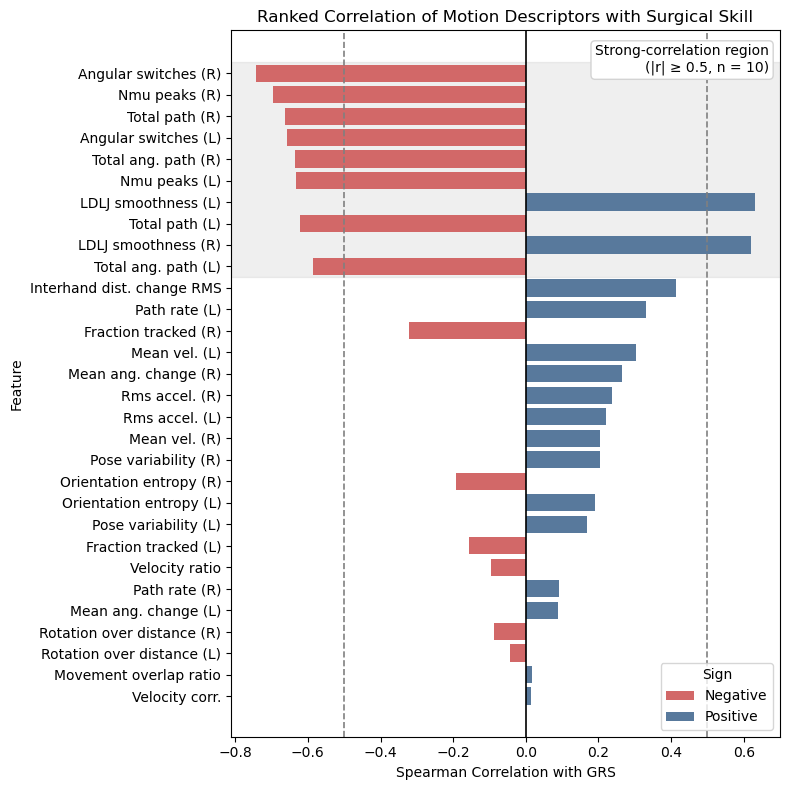

In [3]:
all_features = [col for col in df_full if col not in df_ratings.columns]
df_corr = plot_panel_a_feature_correlations(df_full, all_features, target="QRS_Overal")

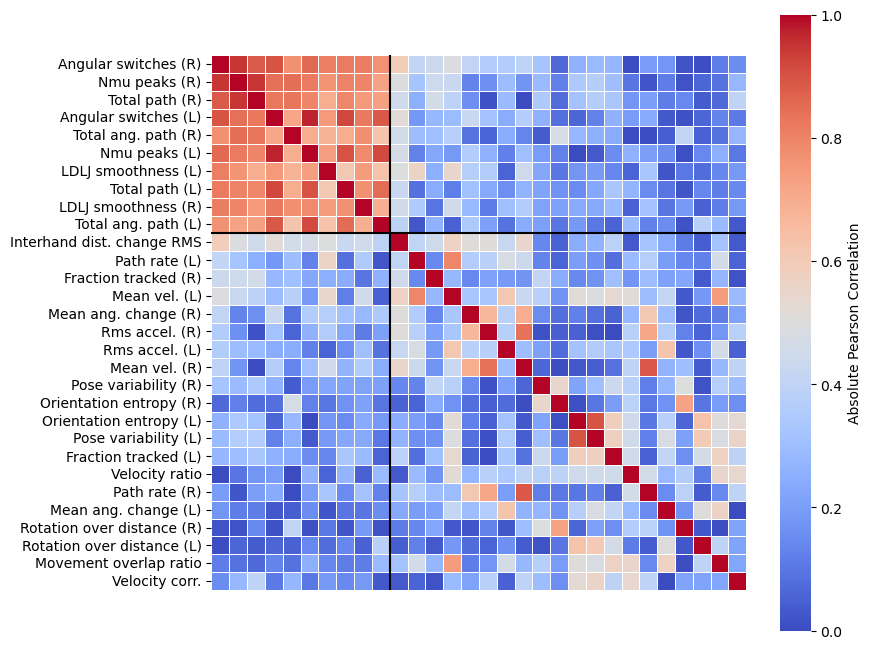

In [24]:
corr_matrix = plot_panel_b_intercorrelation_heatmap(
    df_full,
    df_corr,
    plot_threshold=0.0,
    strong_threshold=0.5
)

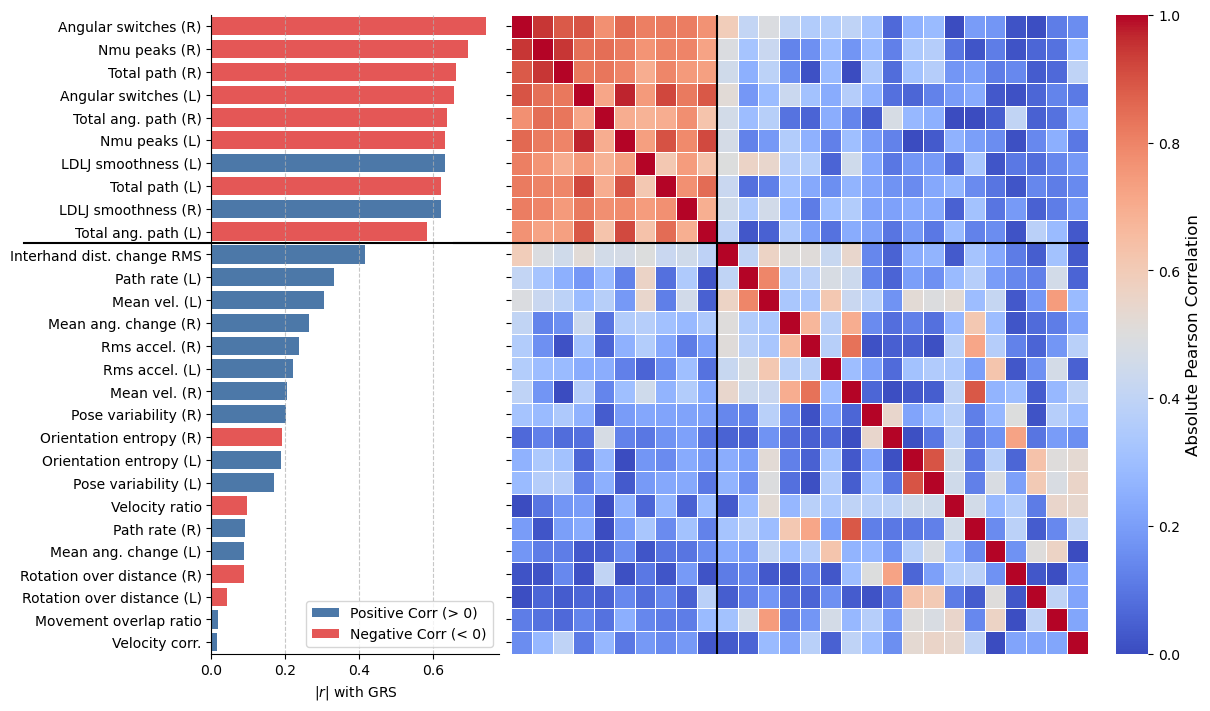

In [25]:
features_plot = [f for f in all_features if not 'Fraction tracked' in f]
df_corr, corr_matrix =plot_combined_feature_screening_figure(
    df_full,
    features_plot,
    target="QRS_Overal",
    strong_threshold=0.5,
    figsize=(12, 7)
)

## Use top Features Only

Extract features that are highly correlated with scores (>0.5) over all folds

In [4]:
# correlation between features and scores
all_features = [col for col in df_full if col not in df_ratings.columns]
right_features = [col for col in all_features if '(R)' in col]
left_features = [col for col in all_features if '(L)' in col]
bimanual_features = [col for col in all_features if col not in right_features+left_features]

fair_corr_df = loso_correlation_analysis(df_full, all_features, n=61)
fair_corr_df

Analyzing Folds: 100%|██████████| 28/28 [00:00<00:00, 31.75it/s]


,Feature,Mean_Corr_with_Target,Std_Corr_with_Target,Min_Corr_with_Target,Max_Corr_with_Target,Selection_Stability
1,Angular switches (R),-0.742295,0.013440,-0.789239,-0.727720,1.0
13,Nmu peaks (R),-0.694672,0.015269,-0.742914,-0.679159,1.0
27,Total path (R),-0.662087,0.017930,-0.709668,-0.644378,1.0
0,Angular switches (L),-0.656689,0.015956,-0.692298,-0.627558,1.0
25,Total ang. path (R),-0.635860,0.013361,-0.662923,-0.618964,1.0
12,Nmu peaks (L),-0.631523,0.017098,-0.662818,-0.594263,1.0
5,LDLJ smoothness (L),0.630559,0.015668,0.605905,0.677119,1.0
26,Total path (L),-0.620902,0.018696,-0.659919,-0.582624,1.0
6,LDLJ smoothness (R),0.619828,0.012562,0.597859,0.647380,1.0
24,Total ang. path (L),-0.584263,0.020874,-0.649853,-0.540950,1.0


In [5]:
top_features = fair_corr_df[(abs(fair_corr_df['Min_Corr_with_Target']) > 0.5) & (abs(fair_corr_df['Max_Corr_with_Target']) > 0.5)]['Feature'].tolist()

# top feature intercorrelation
inter_corrs = df_full[top_features].corr()


top_features_right = [feat for feat in top_features if '(R)' in feat]
top_features_left = [feat for feat in top_features if '(L)' in feat]

In [6]:
top_features_right

['Angular switches (R)',
 'Nmu peaks (R)',
 'Total path (R)',
 'Total ang. path (R)',
 'LDLJ smoothness (R)']

# Try Some Models with these Features
- using all features
- using only the top correlated features

In [7]:
def print_performance(results, title):
    summary = results['summary']
    print(f"=== {title} Results ===")
    print(f"MAE: {summary['MAE']:.4f} ± {summary['MAE_STD']:.4f}")
    print(f"Spearman R:{summary['Spearman_R']:.4f} and R²: {summary['R2']:.4f}\n")

In [8]:
evaluator = LOSOEvaluator(EvaluationConfig(
    target_col="QRS_Overal",
    surgeon_col="Participant Number",
    video_col="video_id",
    device="cpu",
    seed=42,
))

In [14]:
ridge_results = evaluator.evaluate_tabular(
    df=df_full,
    primary_features=all_features,
    model=LassoCV(alphas=np.logspace(-1, 0.5, 20)),
)

print_performance(ridge_results, "LassoCV with All Features")

ridge_results = evaluator.evaluate_tabular(
    df=df_full,
    primary_features=top_features,
    model=LassoCV(alphas=np.logspace(-1, 0.5, 20)),
)

print_performance(ridge_results, "LassoCV with Top Features Only")

ridge_results = evaluator.evaluate_tabular(
    df=df_full,
    primary_features=['Angular switches (R)'],
    model=LinearRegression(),
)
print_performance(ridge_results, "Linear Regression with Angular switches (R) Only")

ridge_results = evaluator.evaluate_tabular(
    df=df_full,
    primary_features=top_features,
    model=RandomForestRegressor(),
)
print_performance(ridge_results, "Random Forest Top Features")

Tabular CV: 100%|██████████| 28/28 [00:02<00:00, 13.09it/s]


=== LassoCV with All Features Results ===
MAE: 5.6987 ± 4.2939
Spearman R:0.6607 and R²: 0.4124



Tabular CV: 100%|██████████| 28/28 [00:01<00:00, 23.18it/s]


=== LassoCV with Top Features Only Results ===
MAE: 5.6492 ± 4.3465
Spearman R:0.6543 and R²: 0.4136



Tabular CV: 100%|██████████| 28/28 [00:00<00:00, 83.78it/s]


=== Linear Regression with Angular switches (R) Only Results ===
MAE: 5.3695 ± 4.1854
Spearman R:0.7249 and R²: 0.4650



Tabular CV: 100%|██████████| 28/28 [00:05<00:00,  4.75it/s]

=== Random Forest Top Features Results ===
MAE: 5.5557 ± 4.3427
Spearman R:0.6531 and R²: 0.4261



# All Top Features are Highly Inter-Correlated
Explore different ways of combining the top correlated features

- Combine all of them with PCA, in one component PC1
- Combine only right features in PC1
- Combine both right and left features in separate right_PC1 + left_PC1

In [30]:
inter_corrs

,Angular switches (R),Nmu peaks (R),Total path (R),Angular switches (L),Nmu peaks (L),LDLJ smoothness (L),Total ang. path (R),LDLJ smoothness (R),Total path (L),Total ang. path (L)
Angular switches (R),1.000000,0.947856,0.886434,0.896690,0.855630,-0.811619,0.773418,-0.815964,0.816461,0.768967
Nmu peaks (R),0.947856,1.000000,0.946420,0.840396,0.818757,-0.763363,0.847045,-0.800735,0.803458,0.725515
Total path (R),0.886434,0.946420,1.000000,0.825805,0.797656,-0.698809,0.829882,-0.747065,0.793139,0.730593
Angular switches (L),0.896690,0.840396,0.825805,1.000000,0.972519,-0.747190,0.717553,-0.821330,0.920183,0.889546
Nmu peaks (L),0.855630,0.818757,0.797656,0.972519,1.000000,-0.737335,0.696750,-0.787495,0.900756,0.917555
LDLJ smoothness (L),-0.811619,-0.763363,-0.698809,-0.747190,-0.737335,1.000000,-0.681598,0.745644,-0.611928,-0.630422
Total ang. path (R),0.773418,0.847045,0.829882,0.717553,0.696750,-0.681598,1.000000,-0.774133,0.697987,0.627234
LDLJ smoothness (R),-0.815964,-0.800735,-0.747065,-0.821330,-0.787495,0.745644,-0.774133,1.000000,-0.772425,-0.694233
Total path (L),0.816461,0.803458,0.793139,0.920183,0.900756,-0.611928,0.697987,-0.772425,1.000000,0.847662
Total ang. path (L),0.768967,0.725515,0.730593,0.889546,0.917555,-0.630422,0.627234,-0.694233,0.847662,1.000000


In [6]:
# with all top features
scaler = StandardScaler()
X = scaler.fit_transform(df_full[top_features].values)

pca = PCA(n_components=len(top_features))
pca.fit(X)
components = pca.components_
explained_variance = pca.explained_variance_ratio_

df = pd.DataFrame(components, columns=top_features)
df['Explained_Variance'] = explained_variance
print('PC1 explained variance:', explained_variance[0])

PC1 explained variance: 0.816643464410691


In [34]:
# right features only
scaler = StandardScaler()
X = scaler.fit_transform(df_full[top_features_right].values)

pca_r = PCA(n_components=len(top_features_right))
pca_r.fit(X)
components = pca_r.components_
explained_variance = pca_r.explained_variance_ratio_

df = pd.DataFrame(components, columns=top_features_right)
df['Explained_Variance'] = explained_variance
print('PC1 explained variance (right features):', explained_variance[0])
pc1_right = pca_r.transform(X)[:, 0]

# left features only
scaler = StandardScaler()
X = scaler.fit_transform(df_full[top_features_left].values)

pca_l = PCA(n_components=len(top_features_left))
pca_l.fit(X)
components = pca_l.components_
explained_variance = pca_l.explained_variance_ratio_
df = pd.DataFrame(components, columns=top_features_left)
df['Explained_Variance'] = explained_variance
print('PC1 explained variance (left features):', explained_variance[0])
pc1_left = pca_l.transform(X)[:, 0]

# corrlation between right and left PC1
correlation = pd.Series(pc1_right).corr(pd.Series(pc1_left))
print('Correlation between right and left PC1:', correlation)

df_full['pc1_left'] = pc1_left

PC1 explained variance (right features): 0.8705575142766632
PC1 explained variance (left features): 0.8583700381604927
Correlation between right and left PC1: 0.8879786905254285


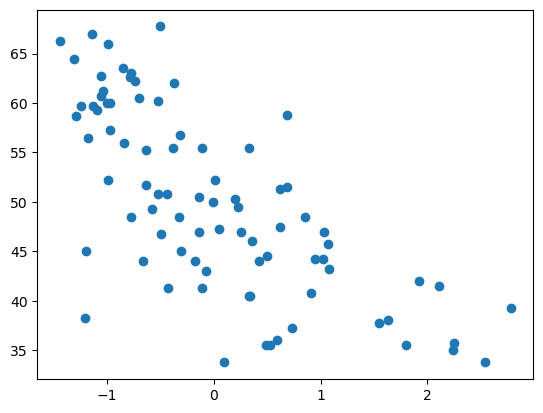

In [20]:
# plot relationship pc1 vs scores
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
scaler = StandardScaler()
plt.scatter(scaler.fit_transform(pc1_right.reshape(-1, 1)), df_full['QRS_Overal'])

## Model With PCA features

In [ ]:
ridge_results = evaluator.evaluate_tabular(
    df=df_full,
    primary_features=top_features,
    extra_features=None,
    model=RidgeCV(alphas=np.logspace(-1, 0.5, 20)),
    pca_components=[0],
    collect_weights=True,
)
print_performance(ridge_results, "RidgeCV with PCA on Top Features")
print(ridge_results['weights'])

Tabular CV:   0%|          | 0/28 [00:00<?, ?it/s]

Tabular CV: 100%|██████████| 28/28 [00:01<00:00, 26.10it/s]


=== RidgeCV with PCA on Top Features Results ===
MAE: 5.4643 ± 3.9245
Spearman R:0.6994 and R²: 0.4776

  Feature  Average_Weight  Std_Weight
0     PC1       -6.524203    0.161776
1    bias       49.938586    0.308361


In [22]:
ridge_results = evaluator.evaluate_tabular(
    df=df_full,
    primary_features=top_features_right,
    extra_features=None,
    model=RidgeCV(alphas=np.logspace(-1, 0.5, 20)),
    pca_components=[0],
    collect_weights=True,
)
print_performance(ridge_results, "RidgeCV with PCA on Right Top Features")
print(ridge_results['weights'])

Tabular CV: 100%|██████████| 28/28 [00:00<00:00, 34.85it/s]

=== RidgeCV with PCA on Right Top Features Results ===
MAE: 5.3522 ± 4.1120
Spearman R:0.6925 and R²: 0.4742

  Feature  Average_Weight  Std_Weight
0     PC1       -6.487758    0.163772
1    bias       49.938586    0.308361


The performance is comparable. Since all participants are right hand dominant, and the first principal component of the top right features only pca captures more varaince this approach is prefered and used as the baseline efficiency feature.

## How Well Do the Remaining Features Explain the Residuals of PC1 only Ridge Model?

In [26]:
# right features only in pc1
candidate_features = [feat for feat in all_features if feat not in top_features_right]

df_res_leakage_free = loso_residual_analysis(df_full, top_features_right, candidate_features=candidate_features, top_n=1, test_other_pcs=True)
df_res_leakage_free

,Feature,Partial_R2_mean,Partial_R2_std,Partial_R2_min,Resid_Corr_mean,Selection_Stability
27,Velocity corr.,0.105394,0.015926,0.050750,-0.305225,0.964286
28,Velocity ratio,0.038402,0.010849,0.014265,-0.194587,0.000000
4,LDLJ smoothness (L),0.030263,0.011788,0.010420,0.121595,0.035714
21,Rms accel. (L),0.026153,0.007404,0.004096,-0.144498,0.000000
6,Mean ang. change (R),0.025603,0.006420,0.013692,0.161108,0.000000
19,Pose variability (L),0.017554,0.006519,0.003695,-0.118642,0.000000
1,Fraction tracked (L),0.016324,0.005731,0.005611,0.115784,0.000000
23,Rotation over distance (L),0.015272,0.008029,0.004285,-0.123909,0.000000
12,Orientation entropy (R),0.013554,0.004990,0.002425,-0.118484,0.000000
16,PCA_Comp_5,0.013499,0.005139,0.002862,0.118799,0.000000


### Hybrid Model PC1 + Velocity Corr

Clear imporvement! 

In [23]:
ridge_results = evaluator.evaluate_tabular(
    df=df_full,
    primary_features=top_features_right,
    extra_features=['Velocity corr.'],
    model=RidgeCV(alphas=np.logspace(-1, 0.5, 20)),
    pca_components=[0],
    collect_weights=True,
)
print_performance(ridge_results, "RidgeCV with Right PC1 + Velocity Corr.")
print(ridge_results['weights'])

Tabular CV: 100%|██████████| 28/28 [00:00<00:00, 34.20it/s]

=== RidgeCV with Right PC1 + Velocity Corr. Results ===
MAE: 5.2511 ± 3.8473
Spearman R:0.7230 and R²: 0.5109

          Feature  Average_Weight  Std_Weight
0             PC1       -7.114179    0.181956
1  Velocity corr.       -2.146442    0.192894
2            bias       49.938586    0.308361


**Interpretation negative velocity correlation weight**

The Novice (High Correlation): Often moves both hands in a "mirroring" or "coupled" fashion because they lack the independent motor control to perform different tasks with each hand. When they move the right hand to pull a thread, the left hand "sympathetically" moves or trembles in the same direction.

The Expert (Lower Correlation): Experts exhibit bimanual functional dissociation. One hand is perfectly still (providing counter-traction) while the other hand moves at high speed. Or, one hand moves left while the other moves up. Their velocity profiles are uncoupled because their hands have specialized roles.

## Statistical Significance?

Running 100 permutations...


100%|██████████| 100/100 [10:40<00:00,  6.41s/it]



--- Significance Results ---
Real Partial R2: 0.1054
Empirical p-value: 0.1100
Z-score vs Null: 1.18


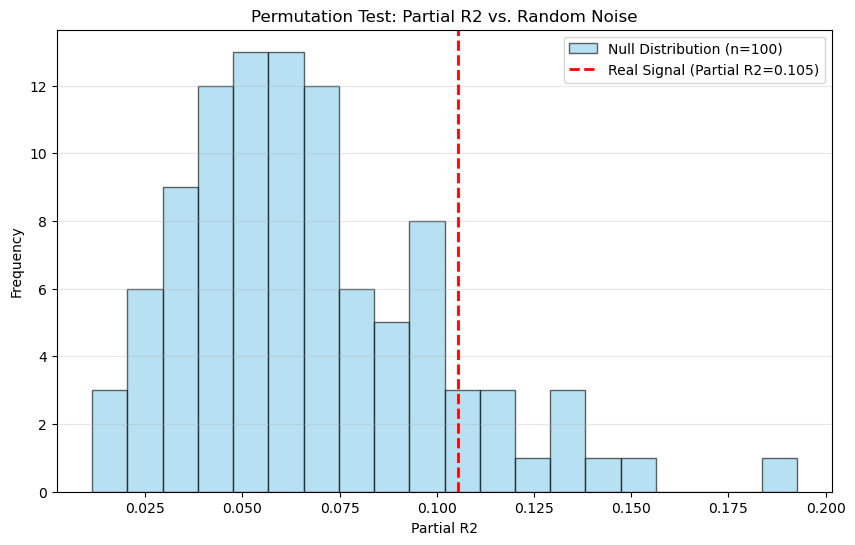

In [ ]:
real_signal = df_res_leakage_free['Partial_R2_mean'].values[0]

# 2. Run the test
results = permutation_significance_test(
    df=df_full,
    top_features_right=top_features_right,
    candidate_features=candidate_features,
    real_val=real_signal,
    n_shuffles=100,
    show_plot=True
)

Empirical p-value: 0.102
Z-score vs Null: 1.43


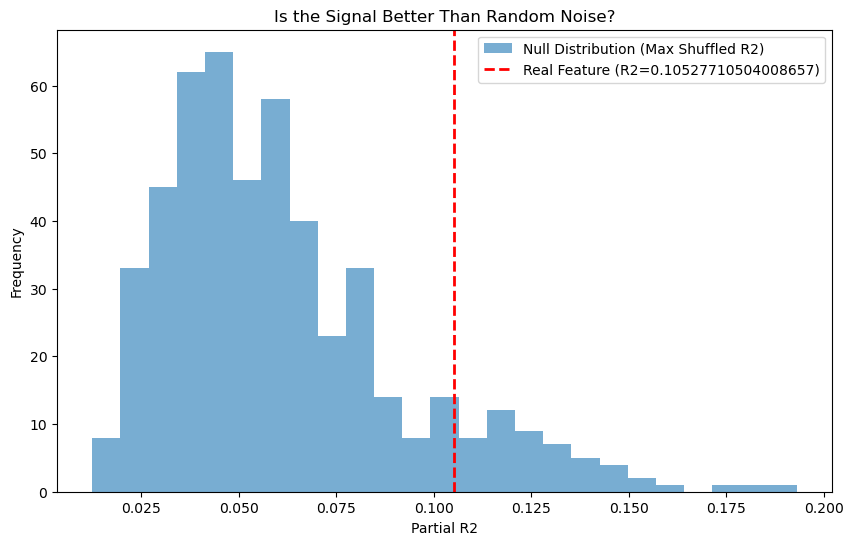

In [ ]:
# TO REMOVE


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
        
# --- DATA INPUT ---
# Your top real feature R2
real_top_r2 = df_res_leakage_free['Partial_R2_mean'].values[0]

# Replace this with your actual list of 50 'Max' Shuffled R2 values 
# (The highest R2 observed in each of the 50 shuffle runs)

shuffled_max_r2s = all_shuffled_r2 # your 50 max values

def evaluate_significance(real_val, null_distribution):
    null_distribution = np.array(null_distribution)
    
    # Empirical p-value: what fraction of the null is >= our real signal?
    p_value = np.mean(null_distribution >= real_val)
    
    # Z-score: how many standard deviations is the real signal from the null mean?
    z_score = (real_val - np.mean(null_distribution)) / np.std(null_distribution)
    
    return p_value, z_score

p_val, z_score = evaluate_significance(real_top_r2, shuffled_max_r2s)

print(f"Empirical p-value: {p_val:.3f}")
print(f"Z-score vs Null: {z_score:.2f}")

# --- VISUALIZATION ---
plt.figure(figsize=(10, 6))
plt.hist(shuffled_max_r2s, bins=25, alpha=0.6, label='Null Distribution (Max Shuffled R2)')
plt.axvline(real_top_r2, color='red', linestyle='--', linewidth=2, label=f'Real Feature (R2={real_top_r2})')
plt.title("Is the Signal Better Than Random Noise?")
plt.xlabel("Partial R2")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Take Different Cases into account

- With Dummy Case variable
- By standarizing the relevant features by case

In [27]:
# one hot encode Case_Number
df_case_onehot = pd.get_dummies(df_full['Case_Number'], prefix='Case').astype(int)

if not any('Case_1' in col for col in df_full.columns):
    df_full = pd.concat([df_full, df_case_onehot], axis=1)

In [28]:
candidate_features = list(set(candidate_features + list(df_case_onehot.columns)))
df_res_leakage_free = loso_residual_analysis(df_full, top_features_right, candidate_features, base_features=['Case_1', 'Case_2', 'Case_3'], top_n=1, test_other_pcs=True)
df_res_leakage_free

,Feature,Partial_R2_mean,Partial_R2_std,Partial_R2_min,Resid_Corr_mean,Selection_Stability
30,Velocity corr.,0.067437,0.013466,0.022095,-0.223426,0.892857
24,Rms accel. (L),0.046501,0.010152,0.014641,-0.180292,0.035714
4,Fraction tracked (L),0.028318,0.006535,0.015272,0.131108,0.000000
15,Orientation entropy (R),0.026486,0.006661,0.011877,-0.149475,0.000000
8,Mean ang. change (L),0.026402,0.007708,0.007681,-0.128556,0.000000
11,Mean vel. (R),0.025506,0.009343,0.006418,-0.093084,0.000000
26,Rotation over distance (L),0.022513,0.010720,0.011915,-0.133576,0.035714
12,Movement overlap ratio,0.018845,0.008680,0.002529,-0.122069,0.000000
31,Velocity ratio,0.017553,0.007405,0.001992,-0.116781,0.000000
7,LDLJ smoothness (L),0.014828,0.008942,-0.000307,0.107232,0.035714


In [29]:
ridge_results = evaluator.evaluate_tabular(
    df=df_full,
    primary_features=top_features_right,
    extra_features=['Case_1', 'Case_2', 'Case_3'],
    model=RidgeCV(alphas=np.logspace(-1, 0.5, 20)),
    pca_components=[0],
    collect_weights=True,
    verbose=False,
)
print_performance(ridge_results, "MLP with Right PC1 + Case Type Dummies")
print(ridge_results['weights'])

=== MLP with Right PC1 + Case Type Dummies Results ===
MAE: 5.2231 ± 3.9821
Spearman R:0.7165 and R²: 0.5021

  Feature  Average_Weight  Std_Weight
0  Case_1       -1.697590    0.108038
1  Case_2       -0.733910    0.175705
2  Case_3        2.431500    0.152522
3     PC1       -6.387588    0.156692
4    bias       49.967973    0.307077


## **NN Model**



In [14]:
from thesis_package.models.mlp_regressor import PyTorchMLPEnsemble

mlp = PyTorchMLPEnsemble(input_dim=4,
                           hidden_dim=16,
                           n_hidden=1,
                           n_models=5,
                           dropout=0.1,
                           batch_size=16)

mlp_results = evaluator.evaluate_tabular(
    df=df_full,
    primary_features=top_features_right,
    extra_features=['Case_1', 'Case_2', 'Case_3'],
    model=mlp,
    pca_components=[0],
    selector=None,
    scale_target=True,
    verbose=False,
    print_fold_metrics=True
)

print_performance(mlp_results, "MLP with Right PC1 + Case Type Dummies")

Fold 1 - Test Group [np.int64(1)]: Test MAE: 6.0200
Fold 2 - Test Group [np.int64(2)]: Test MAE: 3.6797
Fold 3 - Test Group [np.int64(3)]: Test MAE: 8.1145
Fold 4 - Test Group [np.int64(4)]: Test MAE: 4.0739
Fold 5 - Test Group [np.int64(5)]: Test MAE: 6.2593
Fold 6 - Test Group [np.int64(6)]: Test MAE: 1.3490
Fold 7 - Test Group [np.int64(7)]: Test MAE: 9.8142
Fold 8 - Test Group [np.int64(9)]: Test MAE: 3.1912
Fold 9 - Test Group [np.int64(10)]: Test MAE: 3.7542
Fold 10 - Test Group [np.int64(11)]: Test MAE: 1.8811
Fold 11 - Test Group [np.int64(12)]: Test MAE: 4.8305
Fold 12 - Test Group [np.int64(13)]: Test MAE: 2.8965
Fold 13 - Test Group [np.int64(14)]: Test MAE: 9.0486
Fold 14 - Test Group [np.int64(15)]: Test MAE: 7.0359
Fold 15 - Test Group [np.int64(16)]: Test MAE: 8.8824
Fold 16 - Test Group [np.int64(17)]: Test MAE: 3.7539
Fold 17 - Test Group [np.int64(18)]: Test MAE: 5.3352
Fold 18 - Test Group [np.int64(19)]: Test MAE: 8.4180
Fold 19 - Test Group [np.int64(20)]: Test MAE

LOSOCV Ensemble Folds:   0%|          | 0/28 [00:00<?, ?it/s]

Surgeon 1 | Train MAE: 4.2487 | Test MAE: 8.4920 | Test Corr: -0.6482
Surgeon 2 | Train MAE: 4.4993 | Test MAE: 2.4151 | Test Corr: 0.8542
Surgeon 3 | Train MAE: 4.4779 | Test MAE: 4.9538 | Test Corr: 0.9789
Surgeon 4 | Train MAE: 4.3822 | Test MAE: 6.8630 | Test Corr: -0.4047
Surgeon 5 | Train MAE: 4.4217 | Test MAE: 6.1969 | Test Corr: 0.5390
Surgeon 6 | Train MAE: 4.5582 | Test MAE: 1.2298 | Test Corr: 0.9585
Surgeon 7 | Train MAE: 4.3185 | Test MAE: 7.1236 | Test Corr: -0.8604
Surgeon 9 | Train MAE: 4.4185 | Test MAE: 5.5677 | Test Corr: -0.9150
Surgeon 10 | Train MAE: 4.4903 | Test MAE: 5.0523 | Test Corr: 0.8158
Surgeon 11 | Train MAE: 4.4661 | Test MAE: 3.0403 | Test Corr: -0.0418
Surgeon 12 | Train MAE: 4.4581 | Test MAE: 5.0288 | Test Corr: 0.1529
Surgeon 13 | Train MAE: 4.5282 | Test MAE: 3.3189 | Test Corr: 0.8925
Surgeon 14 | Train MAE: 4.5177 | Test MAE: 6.6225 | Test Corr: -0.2237
Surgeon 15 | Train MAE: 4.5394 | Test MAE: 5.7726 | Test Corr: 0.9463
Surgeon 16 | Train MAE

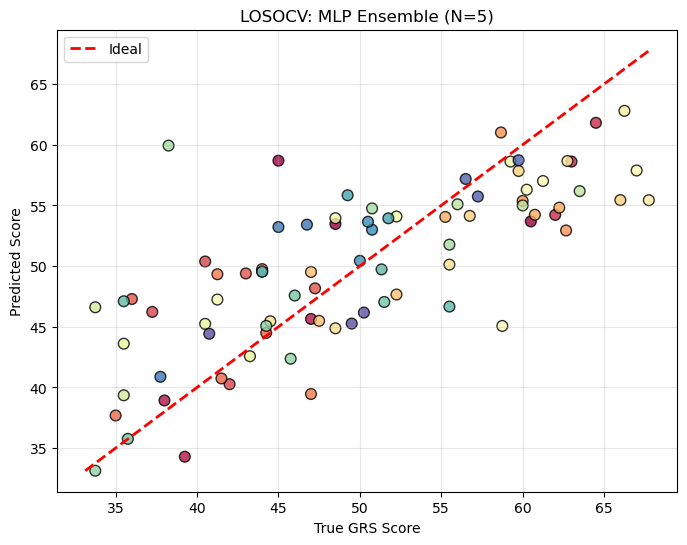

LOSOCV Ensemble Folds:   0%|          | 0/28 [04:26<?, ?it/s]


In [ ]:
from thesis_package.models.mlp_regressor import PyTorchMLPEnsemble
from thesis_package.models.baseline_loso import evaluate_loso_mlp_ensemble

_, _, _ = evaluate_loso_mlp_ensemble(
    model_class=PyTorchMLPEnsemble,
    df=df_full,
    primary_features=top_features,
    extra_features=['velocity_corr'],
    model_params={'hidden_dim': 16, 'n_models': 5, 'dropout': 0.15, 'batch_size': 16},
    pca_components=[0],
    print_fold_metrics=True
)
    


try MLPs with PC1 + velocity_corr + other_features(s)

# Totally data driven nested global feature selection

- take globals with corr > 0.6 from in training fold
- remove those with intercorr > 0.95 (the one with the lower corr with scores)
- PCA of these globals
- selectet out of remaining features using partial r2
- evalue perf

In [158]:
from src_final.models.baseline_loso  import run_automated_nested_loso

results_df, global_stability, local_stability = run_automated_nested_loso(
    df=df_full,
    feature_pool=right_features,
    model_type='ridge',
    model_params={'hidden_dim': 16, 'n_hidden': 2, 'n_models': 5, 'dropout': 0.15, 'batch_size': 16},
    top_n=1,
    print_fold_metrics=True,
    global_corr_threshold=0.5,
    global_redundancy_threshold=0.99,
    corr_threshold=0.8,
    pr2_threshold=0.00,
    #top_n_globals=
)

Surgeon 1 | Globals: 5,  PC1 Explained Var: 0.8715 | Locals: ['velocity_corr'] with PR2s [np.float64(0.1154)]
Surgeon 2 | Globals: 5,  PC1 Explained Var: 0.8681 | Locals: ['velocity_corr'] with PR2s [np.float64(0.1076)]
Surgeon 3 | Globals: 5,  PC1 Explained Var: 0.8688 | Locals: ['velocity_corr'] with PR2s [np.float64(0.0829)]
Surgeon 4 | Globals: 5,  PC1 Explained Var: 0.8716 | Locals: ['velocity_corr'] with PR2s [np.float64(0.1183)]
Surgeon 5 | Globals: 5,  PC1 Explained Var: 0.8721 | Locals: ['velocity_corr'] with PR2s [np.float64(0.1154)]
Surgeon 6 | Globals: 5,  PC1 Explained Var: 0.8613 | Locals: ['velocity_corr'] with PR2s [np.float64(0.0967)]
Surgeon 7 | Globals: 5,  PC1 Explained Var: 0.8700 | Locals: ['velocity_corr'] with PR2s [np.float64(0.1063)]
Surgeon 9 | Globals: 5,  PC1 Explained Var: 0.8675 | Locals: ['velocity_corr'] with PR2s [np.float64(0.1242)]
Surgeon 10 | Globals: 5,  PC1 Explained Var: 0.8706 | Locals: ['velocity_corr'] with PR2s [np.float64(0.1156)]
Surgeon 1

**Store global metrics dataframe for hybrid models**

In [ ]:
cols_to_exclude = ['Age',
 'Gender',
 'Experience_Total',
 'Position',
 'OSATS_Total',
 'CFS_Total',
 'Self_Rating',
 'Vid_Name',
]

cols_to_exclude += candidate_features

df_pc1_features = df_full[[col for col in df_full.columns if col not in cols_to_exclude] + ['Velocity corr.']].copy()

df_pc1_features.to_csv("data/metrics/pc1_features.csv", index=False)